In [ ]:
!pip install pandas
!pip install numpy
%matplotlib inline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

# I. Heat Index
1.) December 2021 to May 2022
      
- we included a '1' in its data/results for identity



In [ ]:
# Upload the Heat Index Data of December 2021 to May 2022
from google.colab import files
uploaded = files.upload()

Saving Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2021-MAY2022.csv to Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2021-MAY2022.csv


In [ ]:
HI1_df = pd.read_csv('Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2021-MAY2022.csv', parse_dates=['Date Hour'])
HI1_df

,Date Hour,Rain (mm),Temperature (Deg C),Dewpoint (Deg C),Relative Humidity (%),Heat Index (Deg C),Solar Radiation (Whr/m2),Air Pressure (hpa),Wind Speed (kph),Wind Gust (kph),Wind Direction,Visibility (km)
0,2022-05-31 23:00:00,0.0,28.0,24.0,79,33,0,"1,009.14",8,21,115,10
1,2022-05-31 22:00:00,0.0,28.0,24.0,78,33,0,"1,009.14",8,21,115,10
2,2022-05-31 21:00:00,0.0,28.0,24.0,78,33,0,"1,008.97",8,21,70,9
3,2022-05-31 20:00:00,0.0,28.0,24.0,77,33,0,"1,008.13",10,26,130,10
4,2022-05-31 19:00:00,0.0,29.0,24.0,77,34,0,"1,007.62",11,29,100,10
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,2021-12-01 04:00:00,0.0,27.0,24.7,89,31,0,"1,008.13",3,-,48,10
4265,2021-12-01 03:00:00,0.0,27.0,24.3,87,32,0,"1,008.13",2,-,103,9
4266,2021-12-01 02:00:00,0.0,27.0,24.8,88,32,0,"1,008.13",3,-,92,9
4267,2021-12-01 01:00:00,0.0,27.0,24.0,87,31,0,"1,008.47",3,-,105,10


In [ ]:
HI1_df.dtypes

Date Hour                   datetime64[ns]
Rain (mm)                          float64
Temperature (Deg C)                float64
Dewpoint (Deg C)                   float64
Relative Humidity (%)                int64
Heat Index (Deg C)                   int64
Solar Radiation (Whr/m2)            object
Air Pressure (hpa)                  object
Wind Speed (kph)                     int64
Wind Gust (kph)                     object
Wind Direction                       int64
Visibility (km)                      int64
dtype: object

In [ ]:
HI1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date Hour                 4269 non-null   datetime64[ns]
 1   Rain (mm)                 4269 non-null   float64       
 2   Temperature (Deg C)       4269 non-null   float64       
 3   Dewpoint (Deg C)          4269 non-null   float64       
 4   Relative Humidity (%)     4269 non-null   int64         
 5   Heat Index (Deg C)        4269 non-null   int64         
 6   Solar Radiation (Whr/m2)  4269 non-null   object        
 7   Air Pressure (hpa)        4269 non-null   object        
 8   Wind Speed (kph)          4269 non-null   int64         
 9   Wind Gust (kph)           4269 non-null   object        
 10  Wind Direction            4269 non-null   int64         
 11  Visibility (km)           4269 non-null   int64         
dtypes: datetime64[ns](1)

In [ ]:
HI1_df.describe()

,Rain (mm),Temperature (Deg C),Dewpoint (Deg C),Relative Humidity (%),Heat Index (Deg C),Wind Speed (kph),Wind Direction,Visibility (km)
count,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000
mean,0.067618,28.067112,22.125603,71.483954,31.253689,9.813071,122.992036,10.578356
std,1.104735,2.733170,1.730124,11.265104,4.555815,5.568287,66.650622,2.123144
min,0.000000,21.200000,16.000000,37.000000,21.000000,0.000000,0.000000,3.000000
25%,0.000000,26.000000,21.000000,63.000000,28.000000,5.000000,85.000000,10.000000
50%,0.000000,28.000000,22.500000,73.000000,31.000000,10.000000,110.000000,10.000000
75%,0.000000,30.000000,23.000000,80.000000,34.000000,13.000000,140.000000,10.000000
max,47.110000,35.000000,26.000000,100.000000,44.000000,34.000000,359.000000,16.000000


In [ ]:
HI1_df['Date Hour']

0      2022-05-31 23:00:00
1      2022-05-31 22:00:00
2      2022-05-31 21:00:00
3      2022-05-31 20:00:00
4      2022-05-31 19:00:00
               ...        
4264   2021-12-01 04:00:00
4265   2021-12-01 03:00:00
4266   2021-12-01 02:00:00
4267   2021-12-01 01:00:00
4268   2021-12-01 00:00:00
Name: Date Hour, Length: 4269, dtype: datetime64[ns]

In [ ]:
HI1_df['Date Hour'] = pd.to_datetime(HI1_df['Date Hour'])

# Set 'Date' as the index
HI1_df.set_index('Date Hour', inplace=True)

# Calculate monthly peaks
HI_monthly_peak1 = HI1_df['Heat Index (Deg C)'].resample('M').max()

# Print the results
print("\nMonthly Peak:")
print(HI_monthly_peak1)


Monthly Peak:
Date Hour
2021-12-31    39
2022-01-31    38
2022-02-28    38
2022-03-31    42
2022-04-30    42
2022-05-31    44
Freq: M, Name: Heat Index (Deg C), dtype: int64


In [ ]:
HI_monthly_peak1.index

DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
               '2022-04-30', '2022-05-31'],
              dtype='datetime64[ns]', name='Date Hour', freq='M')

In [ ]:
datetime_index1 = pd.DatetimeIndex(
    ['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31'])

datetime_index1

DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
               '2022-04-30', '2022-05-31'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
# Convert DatetimeIndex to a NumPy array of datetime64
datetime_array = np.array(datetime_index1, dtype='datetime64')
datetime_array

array(['2021-12-31T00:00:00.000000000', '2022-01-31T00:00:00.000000000',
       '2022-02-28T00:00:00.000000000', '2022-03-31T00:00:00.000000000',
       '2022-04-30T00:00:00.000000000', '2022-05-31T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
HI1_df.shape

(4269, 11)

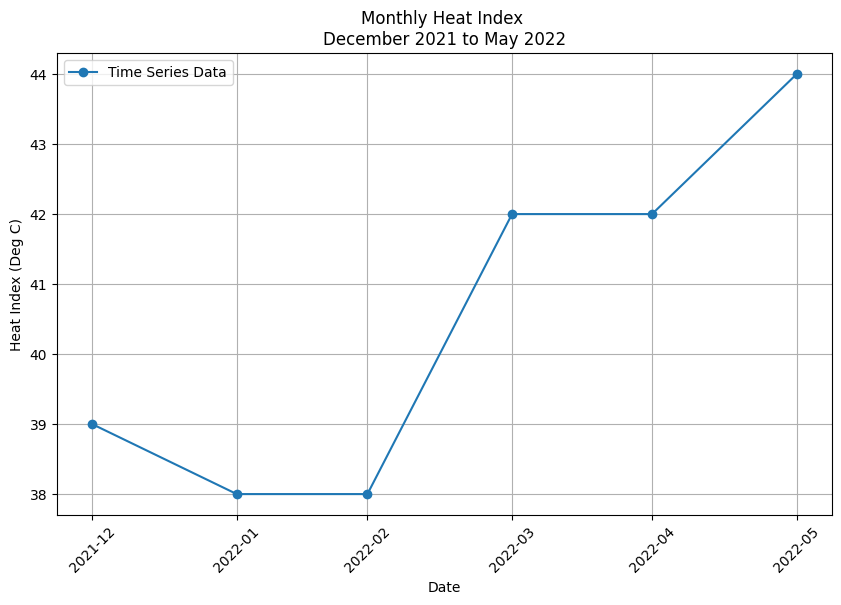

In [ ]:
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(datetime_index1, HI_monthly_peak1, marker='o', label='Time Series Data')
plt.title('Monthly Heat Index \nDecember 2021 to May 2022')
plt.xlabel('Date')
plt.ylabel('Heat Index (Deg C)')
plt.legend()
plt.grid()


# Modify the x-axis ticks
custom_ticks = ['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31']
plt.xticks(pd.to_datetime(custom_ticks), custom_ticks, rotation=45)  # Adjust rotation as needed
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.show()

In [ ]:
# Create a DataFrame with the correct DatetimeIndex
df = pd.DataFrame({'Date': datetime_index1, 'Heat Index': HI_monthly_peak1})
df.set_index('Date', inplace=True)

# Create an interactive Plotly plot
fig = px.line(df, x=df.index, y='Heat Index', markers=True, line_shape='linear', labels={'Heat Index': 'Heat Index (Deg C)'})

# Customize the layout
fig.update_layout(title='Monthly Heat Index from December 2021 to May 2022',
                  xaxis_title='Date',
                  yaxis_title='Heat Index (Deg C)',
                  xaxis=dict(tickmode='array', tickvals=df.index, ticktext=df.index.strftime('%Y-%m'), tickangle=20),
                  showlegend=True,
                  template='plotly_white',
                  )

# Show the interactive plot
fig.show()

2.) December 2022 to May 2023
     
- we included a '2' in its data/results for identity

In [ ]:
# Upload the Heat Index Data of December 2022 to May 2023
from google.colab import files
uploaded = files.upload()

Saving Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2022-MAY2023.csv to Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2022-MAY2023.csv


In [ ]:
HI2_df = pd.read_csv('Mandaluyong City Historical Report_Weather_Table_HEAT_INDEX_DEC2022-MAY2023.csv', parse_dates=['Date Hour'])
HI2_df

,Date Hour,Rain (mm),Temperature (Deg C),Dewpoint (Deg C),Relative Humidity (%),Heat Index (Deg C),Solar Radiation (Whr/m2),Air Pressure (hpa),Wind Speed (kph),Wind Gust (kph),Wind Direction,Visibility (km)
0,2023-05-31 23:00:00,0.0,29.0,26.5,85,37,0,"1,005.08",23,60,265,10
1,2023-05-31 22:00:00,0.0,29.0,26.0,83,37,0,"1,005.08",23,60,260,10
2,2023-05-31 21:00:00,0.0,29.0,26.0,83,37,0,"1,004.57",27,70,250,10
3,2023-05-31 20:00:00,0.0,29.0,26.5,85,37,0,"1,003.56",27,70,250,10
4,2023-05-31 19:00:00,0.0,29.0,26.5,86,37,0,"1,003.05",26,68,250,10
...,...,...,...,...,...,...,...,...,...,...,...,...
4356,2022-12-01 04:00:00,0.0,26.0,23.0,85,29,0,"1,009.65",5,13,100,10
4357,2022-12-01 03:00:00,0.0,26.5,23.0,84,30,0,"1,009.31",5,13,60,9
4358,2022-12-01 02:00:00,0.0,27.0,23.0,82,31,0,"1,009.48",6,16,70,12
4359,2022-12-01 01:00:00,0.0,27.0,23.0,81,31,0,"1,009.99",6,16,60,12


In [ ]:
HI2_df.dtypes

Date Hour                   datetime64[ns]
Rain (mm)                          float64
Temperature (Deg C)                float64
Dewpoint (Deg C)                   float64
Relative Humidity (%)                int64
Heat Index (Deg C)                   int64
Solar Radiation (Whr/m2)             int64
Air Pressure (hpa)                  object
Wind Speed (kph)                     int64
Wind Gust (kph)                      int64
Wind Direction                       int64
Visibility (km)                      int64
dtype: object

In [ ]:
HI2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4361 entries, 0 to 4360
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date Hour                 4361 non-null   datetime64[ns]
 1   Rain (mm)                 4361 non-null   float64       
 2   Temperature (Deg C)       4361 non-null   float64       
 3   Dewpoint (Deg C)          4361 non-null   float64       
 4   Relative Humidity (%)     4361 non-null   int64         
 5   Heat Index (Deg C)        4361 non-null   int64         
 6   Solar Radiation (Whr/m2)  4361 non-null   int64         
 7   Air Pressure (hpa)        4361 non-null   object        
 8   Wind Speed (kph)          4361 non-null   int64         
 9   Wind Gust (kph)           4361 non-null   int64         
 10  Wind Direction            4361 non-null   int64         
 11  Visibility (km)           4361 non-null   int64         
dtypes: datetime64[ns](1)

In [ ]:
HI2_df.describe()

,Rain (mm),Temperature (Deg C),Dewpoint (Deg C),Relative Humidity (%),Heat Index (Deg C),Solar Radiation (Whr/m2),Wind Speed (kph),Wind Gust (kph),Wind Direction,Visibility (km)
count,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000,4361.000000
mean,0.021995,27.891309,22.167278,72.180234,31.226554,81.178629,10.756249,28.089658,128.986471,9.686540
std,0.260020,2.762979,2.038799,10.568761,4.918934,130.307278,6.049336,15.728196,72.627253,0.834258
min,0.000000,22.000000,17.000000,42.000000,22.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,26.000000,21.000000,64.000000,28.000000,0.000000,5.000000,13.000000,80.000000,10.000000
50%,0.000000,27.500000,22.000000,73.000000,31.000000,0.000000,10.000000,26.000000,115.000000,10.000000
75%,0.000000,29.500000,23.500000,80.000000,34.000000,120.000000,14.000000,36.000000,160.000000,10.000000
max,9.660000,36.000000,27.000000,100.000000,46.000000,440.000000,37.000000,96.000000,350.000000,16.000000


In [ ]:
HI2_df['Date Hour']

0      2023-05-31 23:00:00
1      2023-05-31 22:00:00
2      2023-05-31 21:00:00
3      2023-05-31 20:00:00
4      2023-05-31 19:00:00
               ...        
4356   2022-12-01 04:00:00
4357   2022-12-01 03:00:00
4358   2022-12-01 02:00:00
4359   2022-12-01 01:00:00
4360   2022-12-01 00:00:00
Name: Date Hour, Length: 4361, dtype: datetime64[ns]

In [ ]:
HI2_df['Date Hour'] = pd.to_datetime(HI2_df['Date Hour'])

# Set 'Date' as the index
HI2_df.set_index('Date Hour', inplace=True)

In [ ]:
# Calculate hourly, daily, and monthly peaks
HI_monthly_peak2 = HI2_df['Heat Index (Deg C)'].resample('M').max()

# Print the results
print("\nMonthly Peak:")
print(HI_monthly_peak2)


Monthly Peak:
Date Hour
2022-12-31    38
2023-01-31    36
2023-02-28    38
2023-03-31    41
2023-04-30    44
2023-05-31    46
Freq: M, Name: Heat Index (Deg C), dtype: int64


In [ ]:
HI_monthly_peak2.index

DatetimeIndex(['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31',
               '2023-04-30', '2023-05-31'],
              dtype='datetime64[ns]', name='Date Hour', freq='M')

In [ ]:
datetime_index2 = pd.DatetimeIndex(
    ['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31'])

datetime_index2

DatetimeIndex(['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31',
               '2023-04-30', '2023-05-31'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
# Convert DatetimeIndex to a NumPy array of datetime64
datetime_array = np.array(datetime_index2, dtype='datetime64')
datetime_array

array(['2022-12-31T00:00:00.000000000', '2023-01-31T00:00:00.000000000',
       '2023-02-28T00:00:00.000000000', '2023-03-31T00:00:00.000000000',
       '2023-04-30T00:00:00.000000000', '2023-05-31T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
HI2_df.shape

(4361, 11)

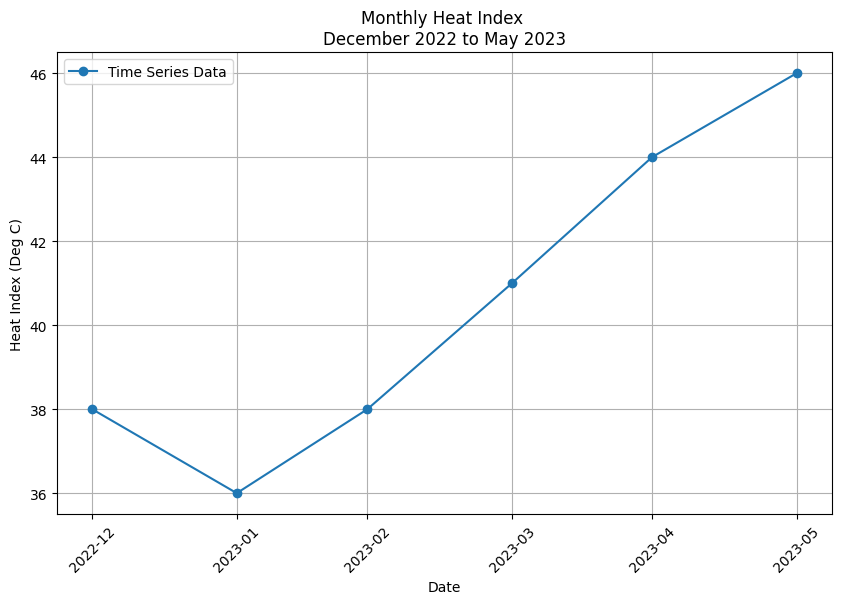

In [ ]:
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(datetime_index2, monthly_peak2, marker='o', label='Time Series Data')
plt.title('Monthly Heat Index \nDecember 2022 to May 2023')
plt.xlabel('Date')
plt.ylabel('Heat Index (Deg C)')
plt.legend()
plt.grid()

# Format the x-axis date labels


# Modify the x-axis ticks
custom_ticks = ['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31']
plt.xticks(pd.to_datetime(custom_ticks), custom_ticks, rotation=45)  # Adjust rotation as needed
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.show()

In [ ]:
# Create a DataFrame with the correct DatetimeIndex
df = pd.DataFrame({'Date': datetime_index2, 'Heat Index': monthly_peak2})
df.set_index('Date', inplace=True)

# Create an interactive Plotly plot
fig = px.line(df, x=df.index, y='Heat Index', markers=True, line_shape='linear', labels={'Heat Index': 'Heat Index (Deg C)'})

# Customize the layout
fig.update_layout(title='Monthly Heat Index \nDecember 2021 to May 2022',
                  xaxis_title='Date',
                  yaxis_title='Heat Index (Deg C)',
                  xaxis=dict(tickmode='array', tickvals=df.index, ticktext=df.index.strftime('%Y-%m'), tickangle=90),
                  showlegend=True,
                  template='plotly_white',
                  )

# Show the interactive plot
fig.show()

# II. Air Pollutants


### 1.) December 2021 to May 2022

- we included a '1' in all of its data/results for identity including its variables


In [ ]:
# Upload the Air Pollutants Data of December 2021 to May 2022
from google.colab import files
uploaded1 = files.upload()

Saving Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2021-MAY2022.csv to Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2021-MAY2022 (1).csv


In [ ]:
AQ1_df = pd.read_csv('Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2021-MAY2022.csv')
AQ1_df

,Date,Particulate Matter 2.5,Particulate Matter 10,Ozone (O3),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2),Ozone (O3).1
0,"May 31, 2022",2.24,3.2,6.8,44,2,0.72,6.83
1,"May 30, 2022",2.78,4.1,9.4,54,4,0.72,9.38
2,"May 29, 2022",2.60,3.8,8.2,52,3,0.72,8.21
3,"May 28, 2022",2.53,3.7,6.4,50,3,0.64,6.41
4,"May 27, 2022",3.74,5.5,12.9,60,3,1.00,12.90
...,...,...,...,...,...,...,...,...
177,"Dec 5, 2021",1.83,3.4,14.0,34,1,0.33,14.03
178,"Dec 4, 2021",1.61,2.7,13.2,34,1,0.30,13.24
179,"Dec 3, 2021",1.43,2.4,12.7,31,1,0.21,12.66
180,"Dec 2, 2021",1.64,2.7,13.0,36,1,0.19,12.98


In [ ]:
AQ1_df.dtypes

Date                       object
Particulate Matter 2.5    float64
Particulate Matter 10     float64
Ozone (O3)                float64
Carbon Monoxide (CO)        int64
Nitrogen Dioxide (NO2)      int64
Sulfur Dioxide (SO2)      float64
Ozone (O3).1              float64
dtype: object

In [ ]:
AQ1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    182 non-null    object 
 1   Particulate Matter 2.5  182 non-null    float64
 2   Particulate Matter 10   182 non-null    float64
 3   Ozone (O3)              182 non-null    float64
 4   Carbon Monoxide (CO)    182 non-null    int64  
 5   Nitrogen Dioxide (NO2)  182 non-null    int64  
 6   Sulfur Dioxide (SO2)    182 non-null    float64
 7   Ozone (O3).1            182 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 11.5+ KB


In [ ]:
AQ1_df.describe()

,Particulate Matter 2.5,Particulate Matter 10,Ozone (O3),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2),Ozone (O3).1
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,2.009890,3.086813,9.974725,41.994505,2.016484,0.709231,9.975879
std,0.830098,1.153731,2.334776,13.824271,1.016305,0.622728,2.334591
min,0.970000,1.500000,5.700000,22.000000,1.000000,0.170000,5.720000
25%,1.447500,2.300000,8.200000,32.000000,1.000000,0.230000,8.162500
50%,1.685000,2.700000,10.000000,38.000000,2.000000,0.485000,9.965000
75%,2.337500,3.500000,11.700000,47.750000,2.000000,1.037500,11.717500
max,5.210000,7.700000,15.900000,95.000000,5.000000,3.630000,15.920000


In [ ]:
AQ1_df.columns = AQ1_df.columns.str.strip()
print(AQ1_df.columns)

Index(['Date', 'Particulate Matter 2.5', 'Particulate Matter 10', 'Ozone (O3)',
       'Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)',
       'Sulfur Dioxide (SO2)', 'Ozone (O3).1'],
      dtype='object')


In [ ]:
AQ1_df['Date'] = pd.to_datetime(AQ1_df['Date'])

# Set 'Date' as the index
AQ1_df.set_index('Date', inplace=True)

A.) Carbon Monoxide (CO)

  - we included a '1' in its data/results for identity of the variable

In [ ]:
# Calculate monthly peak of Carbon Monoxide (CO) values
CO_monthly_peak1 = AQ1_df['Carbon Monoxide (CO)'].resample('M').max()

# Print the results
print("Carbon Monoxide (CO) Monthly Peak CO:")
print(CO_monthly_peak1)

Carbon Monoxide (CO) Monthly Peak CO:
Date
2021-12-31    63
2022-01-31    83
2022-02-28    56
2022-03-31    61
2022-04-30    90
2022-05-31    95
Freq: M, Name: Carbon Monoxide (CO), dtype: int64


B.) Nitrogen Dioxide (NO2)

   - we included a '1' in its data/results for identity of the variable

In [ ]:
# Calculate monthly peak of Nitrogen Dioxide (NO2) values
NO2_monthly_peak1 = AQ1_df['Nitrogen Dioxide (NO2)'].resample('M').max()

# Print the results
print("Nitrogen Dioxide (NO2) Monthly Peak CO:")
print(NO2_monthly_peak1)

Nitrogen Dioxide (NO2) Monthly Peak CO:
Date
2021-12-31    4
2022-01-31    4
2022-02-28    3
2022-03-31    3
2022-04-30    5
2022-05-31    5
Freq: M, Name: Nitrogen Dioxide (NO2), dtype: int64


C.) Sulfur Dioxide (SO2)

   - we included a '1' in its data/results for identity of the variable

In [ ]:
# Calculate monthly peak of Sulfur Dioxide (SO2) values
SO2_monthly_peak1 = AQ1_df['Sulfur Dioxide (SO2)'].resample('M').max()

# Print or use the results as needed
print("Sulfur Dioxide (SO2) Monthly Peak CO:")
print(SO2_monthly_peak1)

Sulfur Dioxide (SO2) Monthly Peak CO:
Date
2021-12-31    1.03
2022-01-31    1.39
2022-02-28    3.02
2022-03-31    3.63
2022-04-30    1.99
2022-05-31    1.66
Freq: M, Name: Sulfur Dioxide (SO2), dtype: float64


In [ ]:
datetime_index = pd.DatetimeIndex(
    ['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31'])

datetime_index


DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
               '2022-04-30', '2022-05-31'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
# Convert DatetimeIndex to a NumPy array of datetime64
datetime_array = np.array(datetime_index, dtype='datetime64')
datetime_array

array(['2021-12-31T00:00:00.000000000', '2022-01-31T00:00:00.000000000',
       '2022-02-28T00:00:00.000000000', '2022-03-31T00:00:00.000000000',
       '2022-04-30T00:00:00.000000000', '2022-05-31T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
CO_monthly_peak1.index
NO2_monthly_peak1.index
SO2_monthly_peak1.index
AQ_monthly_peak1 = (CO_monthly_peak1.index, NO2_monthly_peak1.index, SO2_monthly_peak1.index)
AQ_monthly_peak1

(DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
                '2022-04-30', '2022-05-31'],
               dtype='datetime64[ns]', name='Date', freq='M'),
 DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
                '2022-04-30', '2022-05-31'],
               dtype='datetime64[ns]', name='Date', freq='M'),
 DatetimeIndex(['2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
                '2022-04-30', '2022-05-31'],
               dtype='datetime64[ns]', name='Date', freq='M'))

In [ ]:
AQ1_df.shape

(182, 7)

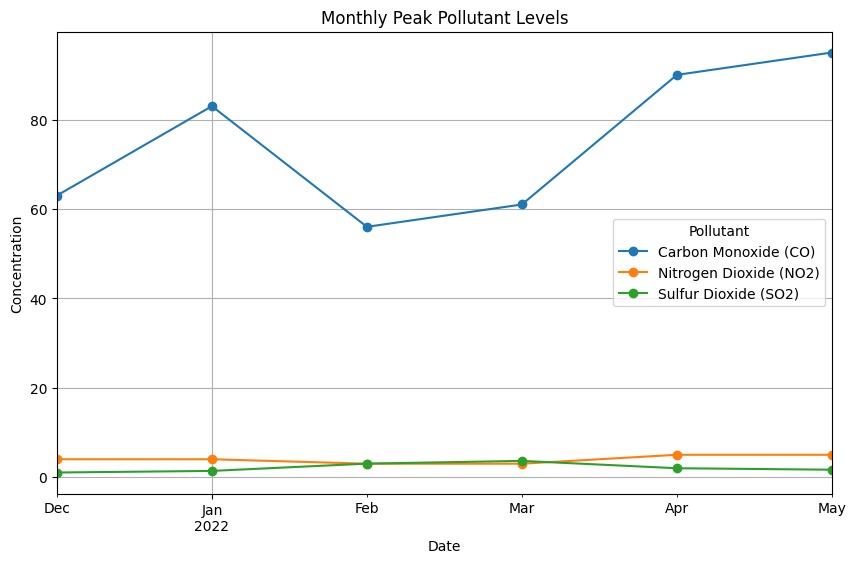

In [ ]:
monthly_peaks_combined1 = pd.DataFrame({
    'Carbon Monoxide (CO)': CO_monthly_peak1,
    'Nitrogen Dioxide (NO2)': NO2_monthly_peak1,
    'Sulfur Dioxide (SO2)': SO2_monthly_peak1})

# Plot the data
plt.figure(figsize=(10, 6))
monthly_peaks_combined1.plot(marker='o', linestyle='-', ax=plt.gca())
plt.title('Monthly Peak Pollutant Levels')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend(title='Pollutant')
plt.grid()
plt.show()

### 2.) December 2022 to May 2023

- we included a '2' in all of its data/results for identity including its variables

In [ ]:
# Upload the Air Pollutants Data of December 2022 to May 2023
from google.colab import files
uploaded2 = files.upload()

Saving Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2022-MAY2023.csv to Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2022-MAY2023.csv


In [ ]:
AQ2_df = pd.read_csv('Mandaluyong City Historical Report_Air Quality_Table_AIR_POLLUTANTS_DEC2022-MAY2023.csv')
AQ2_df

,Date,Particulate Matter 2.5,Particulate Matter 10,Ozone (O3),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2),Ozone (O3).1
0,"May 31, 2023",1.64,2.7,9.5,33,1,0.37,9.47
1,"May 30, 2023",1.56,2.7,9.8,33,1,0.59,9.77
2,"May 29, 2023",1.47,2.5,8.5,30,1,0.35,8.53
3,"May 28, 2023",3.62,5.4,17.0,60,2,1.11,17.03
4,"May 27, 2023",4.27,6.4,17.8,73,3,1.63,17.79
...,...,...,...,...,...,...,...,...
177,"Dec 5, 2022",1.44,2.1,7.4,42,3,0.17,7.37
178,"Dec 4, 2022",1.20,1.8,7.7,33,2,0.22,7.69
179,"Dec 3, 2022",1.37,2.1,8.6,31,2,0.23,8.60
180,"Dec 2, 2022",1.25,2.0,8.2,29,2,0.21,8.21


In [ ]:
AQ2_df.dtypes

Date                       object
Particulate Matter 2.5    float64
Particulate Matter 10     float64
Ozone (O3)                float64
Carbon Monoxide (CO)        int64
Nitrogen Dioxide (NO2)      int64
Sulfur Dioxide (SO2)      float64
Ozone (O3).1              float64
dtype: object

In [ ]:
AQ2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    182 non-null    object 
 1   Particulate Matter 2.5  182 non-null    float64
 2   Particulate Matter 10   182 non-null    float64
 3   Ozone (O3)              182 non-null    float64
 4   Carbon Monoxide (CO)    182 non-null    int64  
 5   Nitrogen Dioxide (NO2)  182 non-null    int64  
 6   Sulfur Dioxide (SO2)    182 non-null    float64
 7   Ozone (O3).1            182 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 11.5+ KB


In [ ]:
AQ2_df.describe()

,Particulate Matter 2.5,Particulate Matter 10,Ozone (O3),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2),Ozone (O3).1
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,2.459231,3.766484,11.629121,47.274725,2.115385,1.060934,11.627363
std,1.501592,2.133093,2.932063,23.843442,1.314133,1.067449,2.934278
min,1.060000,1.600000,5.700000,25.000000,1.000000,0.170000,5.650000
25%,1.492500,2.400000,9.500000,33.000000,1.000000,0.342500,9.472500
50%,1.845000,3.000000,11.250000,39.000000,2.000000,0.670000,11.275000
75%,2.892500,4.275000,13.475000,52.750000,2.000000,1.412500,13.435000
max,8.980000,12.900000,21.400000,155.000000,8.000000,6.190000,21.380000


In [ ]:
AQ2_df.columns = AQ2_df.columns.str.strip()
print(AQ2_df.columns)

Index(['Date', 'Particulate Matter 2.5', 'Particulate Matter 10', 'Ozone (O3)',
       'Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)',
       'Sulfur Dioxide (SO2)', 'Ozone (O3).1'],
      dtype='object')


In [ ]:
AQ2_df['Date'] = pd.to_datetime(AQ2_df['Date'])

# Set 'Date' as the index
AQ2_df.set_index('Date', inplace=True)

A.) Carbon Monoxide (CO)



In [ ]:
# Calculate monthly peak of Carbon Monoxide (CO) values
CO_monthly_peak2 = AQ2_df['Carbon Monoxide (CO)'].resample('M').max()

# Print the results
print("Carbon Monoxide (CO) Monthly Peak CO:")
print(CO_monthly_peak2)

Carbon Monoxide (CO) Monthly Peak CO:
Date
2022-12-31    142
2023-01-31     78
2023-02-28    145
2023-03-31     52
2023-04-30    155
2023-05-31     87
Freq: M, Name: Carbon Monoxide (CO), dtype: int64


B.) Nitrogen Dioxide (NO2)


In [ ]:
# Calculate monthly peak of Nitrogen Dioxide (NO2) values
NO2_monthly_peak2 = AQ2_df['Nitrogen Dioxide (NO2)'].resample('M').max()

# Print the results
print("Nitrogen Dioxide (NO2) Monthly Peak CO:")
print(NO2_monthly_peak2)

Nitrogen Dioxide (NO2) Monthly Peak CO:
Date
2022-12-31    8
2023-01-31    5
2023-02-28    7
2023-03-31    3
2023-04-30    6
2023-05-31    5
Freq: M, Name: Nitrogen Dioxide (NO2), dtype: int64


C.) Sulfur Dioxide (SO2)





In [ ]:
# Calculate monthly peak of Sulfur Dioxide (SO2) values
SO2_monthly_peak2 = AQ2_df['Sulfur Dioxide (SO2)'].resample('M').max()

# Print or use the results as needed
print("Sulfur Dioxide (SO2) Monthly Peak CO:")
print(SO2_monthly_peak2)

Sulfur Dioxide (SO2) Monthly Peak CO:
Date
2022-12-31    2.90
2023-01-31    1.62
2023-02-28    2.67
2023-03-31    2.54
2023-04-30    6.19
2023-05-31    3.55
Freq: M, Name: Sulfur Dioxide (SO2), dtype: float64


In [ ]:
datetime_index = pd.DatetimeIndex(
    ['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31'])

datetime_index

DatetimeIndex(['2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31',
               '2023-04-30', '2023-05-31'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
# Convert DatetimeIndex to a NumPy array of datetime64
datetime_array = np.array(datetime_index, dtype='datetime64')
datetime_array

array(['2022-12-31T00:00:00.000000000', '2023-01-31T00:00:00.000000000',
       '2023-02-28T00:00:00.000000000', '2023-03-31T00:00:00.000000000',
       '2023-04-30T00:00:00.000000000', '2023-05-31T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
AQ2_df.shape

(182, 7)

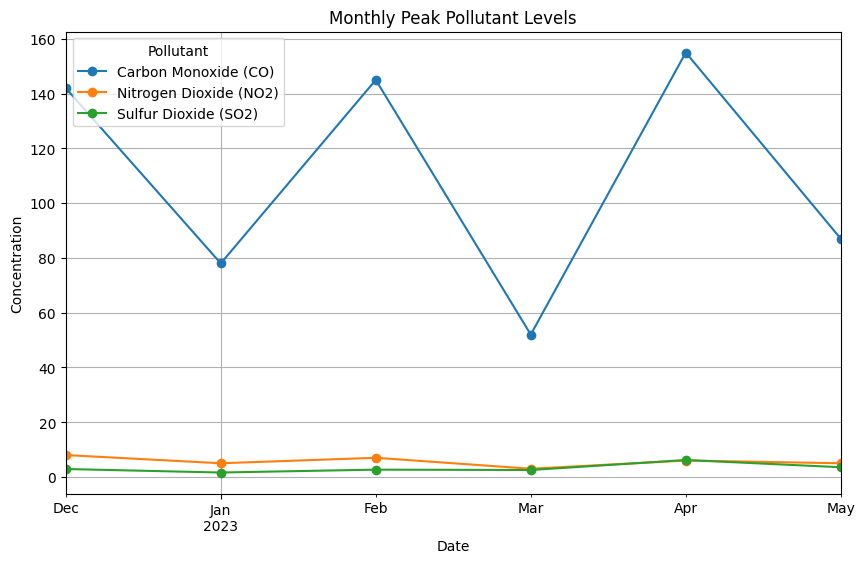

In [ ]:
monthly_peaks_combined = pd.DataFrame({
    'Carbon Monoxide (CO)': CO_monthly_peak2,
    'Nitrogen Dioxide (NO2)': NO2_monthly_peak2,
    'Sulfur Dioxide (SO2)': SO2_monthly_peak2})

# Plot the data
plt.figure(figsize=(10, 6))
monthly_peaks_combined.plot(marker='o', linestyle='-', ax=plt.gca())
plt.title('Monthly Peak Pollutant Levels')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend(title='Pollutant')
plt.grid()
plt.show()

## III. Statistical Analysis of Heat Index and Air Pollutants (Carbon Monoxide (CO), Nitrogen Dioxide (NO2), and Sulfur Dioxide (SO2))

1.) Multiple Linear Regression of Dry Season (December 2021 - May 2022)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
df0 = { 'Date' : ['2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05'],
         'Heat Index (Deg C)': [39,38, 38,42,42, 44],
         'Carbon Monoxide (CO)': [63, 83, 56, 61, 90, 95],
         'Nitrogen Dioxide (NO2)': [4,4, 3, 3, 5, 5],
         'Sulfur Dioxide (SO2)': [1.03, 1.39, 3.02, 3.63, 1.99, 1.66]}

MLR_df0 = pd.DataFrame(df0)
MLR_df0

,Date,Heat Index (Deg C),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2)
0,2021-12,39,63,4,1.03
1,2022-01,38,83,4,1.39
2,2022-02,38,56,3,3.02
3,2022-03,42,61,3,3.63
4,2022-04,42,90,5,1.99
5,2022-05,44,95,5,1.66


In [ ]:
# Add a constant term to the independent variables matrix
X = sm.add_constant(MLR_df0[['Heat Index (Deg C)', 'Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)', 'Sulfur Dioxide (SO2)']])

# Dependent variable
y = MLR_df0['Heat Index (Deg C)']

# Fit the regression model
model_df0 = sm.OLS(y, X).fit()

# Print the regression results
print(model_df0.summary())

                            OLS Regression Results                            
Dep. Variable:     Heat Index (Deg C)   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.983e+26
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           3.36e-14
Time:                        17:08:53   Log-Likelihood:                 175.09
No. Observations:                   6   AIC:                            -340.2
Df Residuals:                       1   BIC:                            -341.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -2.84

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# Get p-values from the model
p_values = model_df0.pvalues

# Display p-values
print("P-values:")
display(p_values)

# Adjust the significance level (e.g., from 0.05 to 0.01)
adjusted_alpha = 0.01
reject_null = p_values < adjusted_alpha

# Print the result of the hypothesis test for each coefficient
print("\nHypothesis test result:")
for i, (param, p_val, reject) in enumerate(zip(model_df0.params.index, p_values, reject_null)):
    print(f"{i + 1}. {param}: p-value = {p_val:.4f} {'(Reject H0)' if reject else '(Fail to reject H0)'}")

P-values:


const                     9.833010e-01
Heat Index (Deg C)        2.705237e-14
Carbon Monoxide (CO)      9.600092e-01
Nitrogen Dioxide (NO2)    1.000000e+00
Sulfur Dioxide (SO2)      1.000000e+00
dtype: float64


Hypothesis test result:
1. const: p-value = 0.9833 (Fail to reject H0)
2. Heat Index (Deg C): p-value = 0.0000 (Reject H0)
3. Carbon Monoxide (CO): p-value = 0.9600 (Fail to reject H0)
4. Nitrogen Dioxide (NO2): p-value = 1.0000 (Fail to reject H0)
5. Sulfur Dioxide (SO2): p-value = 1.0000 (Fail to reject H0)


In [ ]:
# Get p-values for the coefficients
p_values = model_df0.pvalues
print("\nP-values for coefficients:")
print(p_values)


P-values for coefficients:
const                     9.833010e-01
Heat Index (Deg C)        2.705237e-14
Carbon Monoxide (CO)      9.600092e-01
Nitrogen Dioxide (NO2)    1.000000e+00
Sulfur Dioxide (SO2)      1.000000e+00
dtype: float64


In [ ]:
MLR_df0.shape

(6, 5)

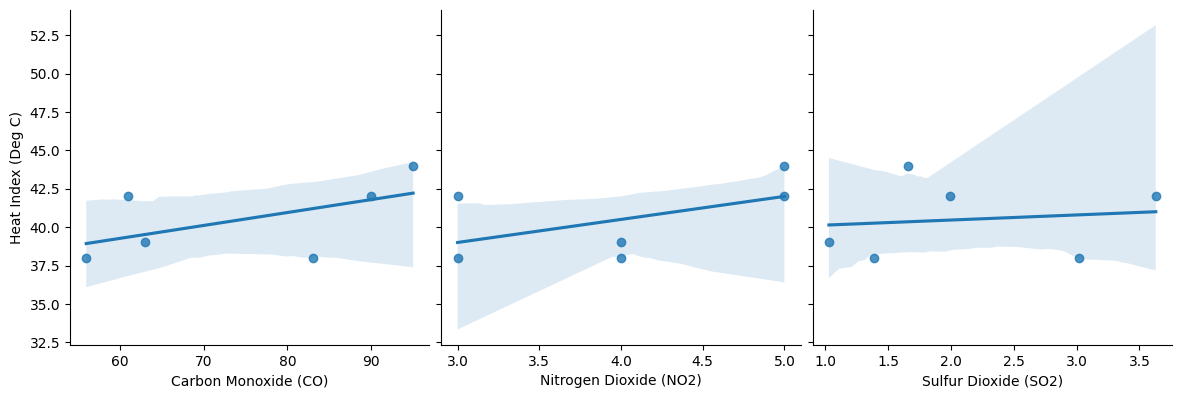

In [ ]:
sns.pairplot(MLR_df0, x_vars=['Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)', 'Sulfur Dioxide (SO2)'], y_vars='Heat Index (Deg C)', kind='reg', height = 4)
plt.show()

In [ ]:

df1 = {'Date' : ['2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05'],
         'Heat Index (Deg C)': ['38', '36', '38', '41', '44', '46'],
         'Carbon Monoxide (CO)': ['142', '78', '145', '52', '155', '87'],
         'Nitrogen Dioxide (NO2)': ['8', '5', '7', '3', '6', '5'],
         'Sulfur Dioxide (SO2)': ['2.90', '1.62', '2.67', '2.54', '6.19', '3.55']}

MLR_df1 = pd.DataFrame(df1)
MLR_df1

,Date,Heat Index (Deg C),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2)
0,2022-12,38,142,8,2.90
1,2023-01,36,78,5,1.62
2,2023-02,38,145,7,2.67
3,2023-03,41,52,3,2.54
4,2023-04,44,155,6,6.19
5,2023-05,46,87,5,3.55


In [ ]:
# @title

# Assuming 'your_dataframe' is your DataFrame variable
data = MLR_df1.values

# Check data types with np.asarray
converted_MLR = np.asarray(data)

# Update the DataFrame with the corrected data types
CMLR_df1 = pd.DataFrame(converted_MLR, columns=MLR_df1.columns)
CMLR_df1

,Date,Heat Index (Deg C),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2)
0,2022-12,38,142,8,2.90
1,2023-01,36,78,5,1.62
2,2023-02,38,145,7,2.67
3,2023-03,41,52,3,2.54
4,2023-04,44,155,6,6.19
5,2023-05,46,87,5,3.55


In [ ]:
MLR_df1.dtypes

Date                      object
Heat Index (Deg C)        object
Carbon Monoxide (CO)      object
Nitrogen Dioxide (NO2)    object
Sulfur Dioxide (SO2)      object
dtype: object

In [ ]:
MLR_df1['Date'] = pd.to_datetime(MLR_df1['Date'], format='%Y-%m').dt.to_period('M')
cols_to_convert = ['Heat Index (Deg C)', 'Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)', 'Sulfur Dioxide (SO2)']

In [ ]:
MLR_df1.dtypes

Date                      period[M]
Heat Index (Deg C)           object
Carbon Monoxide (CO)         object
Nitrogen Dioxide (NO2)       object
Sulfur Dioxide (SO2)         object
dtype: object

In [ ]:
MLR_df1[cols_to_convert] = MLR_df1[cols_to_convert].apply(pd.to_numeric, errors='coerce')
print(MLR_df1.dtypes)
MLR_df1

Date                      period[M]
Heat Index (Deg C)            int64
Carbon Monoxide (CO)          int64
Nitrogen Dioxide (NO2)        int64
Sulfur Dioxide (SO2)        float64
dtype: object


,Date,Heat Index (Deg C),Carbon Monoxide (CO),Nitrogen Dioxide (NO2),Sulfur Dioxide (SO2)
0,2022-12,38,142,8,2.90
1,2023-01,36,78,5,1.62
2,2023-02,38,145,7,2.67
3,2023-03,41,52,3,2.54
4,2023-04,44,155,6,6.19
5,2023-05,46,87,5,3.55


In [ ]:
# Add a constant term to the independent variables matrix
X = sm.add_constant(MLR_df1[['Heat Index (Deg C)', 'Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)', 'Sulfur Dioxide (SO2)']])

# Dependent variable
y = MLR_df1['Heat Index (Deg C)']

# Fit the regression model
model_df1 = sm.OLS(y, X).fit()

# Print the regression results
print(model_df1.summary())

                            OLS Regression Results                            
Dep. Variable:     Heat Index (Deg C)   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.494e+26
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           6.14e-14
Time:                        16:18:17   Log-Likelihood:                 168.85
No. Observations:                   6   AIC:                            -327.7
Df Residuals:                       1   BIC:                            -328.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -2.84

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# Get p-values from the model
p_values = model_df1.pvalues

# Display p-values
print("P-values:")
display(p_values)

# Adjust the significance level (e.g., from 0.05 to 0.01)
adjusted_alpha = 0.01
reject_null = p_values < adjusted_alpha

# Print the result of the hypothesis test for each coefficient
print("\nHypothesis test result:")
for i, (param, p_val, reject) in enumerate(zip(model_df1.params.index, p_values, reject_null)):
    print(f"{i + 1}. {param}: p-value = {p_val:.4f} {'(Reject H0)' if reject else '(Fail to reject H0)'}")

P-values:


const                     9.941795e-01
Heat Index (Deg C)        5.559454e-14
Carbon Monoxide (CO)      9.798271e-01
Nitrogen Dioxide (NO2)    9.773460e-01
Sulfur Dioxide (SO2)      9.938056e-01
dtype: float64


Hypothesis test result:
1. const: p-value = 0.9942 (Fail to reject H0)
2. Heat Index (Deg C): p-value = 0.0000 (Reject H0)
3. Carbon Monoxide (CO): p-value = 0.9798 (Fail to reject H0)
4. Nitrogen Dioxide (NO2): p-value = 0.9773 (Fail to reject H0)
5. Sulfur Dioxide (SO2): p-value = 0.9938 (Fail to reject H0)


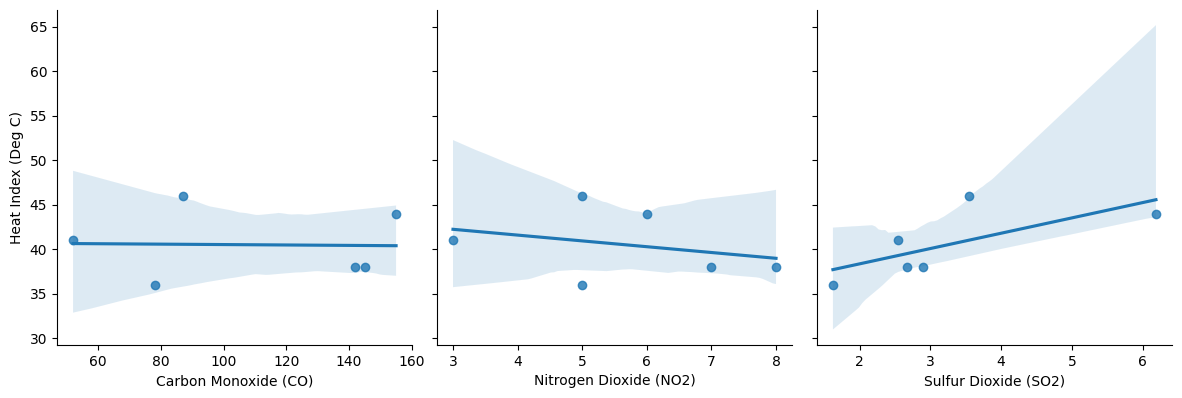

In [ ]:
sns.pairplot(MLR_df1, x_vars=['Carbon Monoxide (CO)', 'Nitrogen Dioxide (NO2)', 'Sulfur Dioxide (SO2)'], y_vars='Heat Index (Deg C)', kind='reg', height = 4)
plt.show()

2.) Pearson R

In [ ]:
!pip install scipy

In [ ]:
from scipy.stats import pearsonr

In [ ]:
correlation_heat_co, _ = pearsonr(MLR_df1['Heat Index (Deg C)'], MLR_df1['Carbon Monoxide (CO)'])
correlation_heat_no2, _ = pearsonr(MLR_df1['Heat Index (Deg C)'], MLR_df1['Nitrogen Dioxide (NO2)'])
correlation_heat_so2, _ = pearsonr(MLR_df1['Heat Index (Deg C)'], MLR_df1['Sulfur Dioxide (SO2)'])


In [ ]:
print(f"Pearson correlation between heat index and CO: {correlation_heat_co}")
print(f"Pearson correlation between heat index and NO2: {correlation_heat_no2}")
print(f"Pearson correlation between heat index and SO2: {correlation_heat_so2}")

Pearson correlation between heat index and CO: -0.025809972318832294
Pearson correlation between heat index and NO2: -0.29390585352155807
Pearson correlation between heat index and SO2: 0.6956501554483528
